# AI Model Experiment & Evaluation
**Starter Notebook**

Notebook ini adalah kerangka awal untuk membandingkan dua pendekatan AI dalam menyelesaikan task sentiment analysis ulasan pelanggan:
1. Model klasik Machine Learning (Scikit-learn)
2. LLM API (Gemini)

Isi tiap section sesuai instruksi di Assignment Brief. Jangan ubah struktur section, tapi silakan tambah cell baru di dalam tiap section jika diperlukan.

> 🔧 **Catatan Penyesuaian Dataset**
>
> Notebook ini menggunakan dataset `customer_reviews_sentiment.csv` dengan kolom `review_text` dan `sentiment` (nilai: `positif`/`negatif`).
>
> Apabila dataset final berbeda dari yang digunakan saat ini, sesuaikan bagian berikut:
> - Nama file pada `pd.read_csv(...)` di Section 2
> - Nama kolom teks dan label pada Section 3 (saat ini: `review_text`, `sentiment`)
> - Label yang diminta pada prompt LLM di Section 5.2 (saat ini: `positif`/`negatif`)
> - Studi Kasus pada Assignment Brief, apabila domain data berbeda dari e-commerce

## 1. Problem Statement

### Objective Use Case
Menentukan pendekatan yang sesuai untuk membangun fitur otomatis klasifikasi sentimen ulasan pelanggan (positif/negatif) pada halaman produk, dari perbandingan eksperimen menggunakan model klasik (Scikit-learn) dan LLM API (Gemini).

### Target/Label
Bentuk label 1/0
- 1 (Positif) : Ulasan bersifat positif (menyatakan kepuasan, pujian, atau rekomendasi) terhadap produk
- 0 (Negatif) : Ulasan bersifat negatif (menyatakan kekecewaan, keluhan, atau kritik) terhadap produk

### Batasan dan Asumsi
- Klasifikasi biner (positif/negatif); ulasan netral tidak digunakan
- Dataset yang digunakan bahasa Indonesia dengan jumlah 200 ulasan
- Metrik penilaian yang dipakai yaitu accuracy, precision, recall, F1, latency, dan biaya per prediksi
- Label di dataset dianggap benar dan mewakili sentimen sebenarnya
- Kedua pendekatan model klasik maupun LLM API dievaluasi pada test set yang sama supaya perbandingannya adil
- Pembagian train dan test set sebesar 80/20 (160 train, 40 test)
- Untuk awal percobaan Gemini dipakai secara zero-shot tanpa fine-tuning, dengan temperature 0 agar output konsisten.
- Karena dataset kecil (200 ulasan), hasil eksperimen belum tentu mewakili performa pada data produksi. Tetapi dari 200 baris,  hanya 40 ulasan unik (160 train, 40 test) → (32 train, 8 test). Jadi test set hanya 8 ulasan, jadi satu prediksi salah saja sudah menurunkan akurasi 12,5%.


## 2. Import Library & Load Dataset

In [4]:
pip install scikit-learn

In [71]:
# 🔧 Sesuaikan nama file jika dataset final berbeda
import os
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from google import genai  # sesuaikan dengan library Gemini API yang digunakan
from google.genai import types, errors

DATA_PATH = '../data/customer_reviews_sentiment.csv'  # lokal (VS Code)
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'customer_reviews_sentiment.csv'  # Google Colab: upload CSV lewat panel Files

df = pd.read_csv(DATA_PATH)
df.head()

,review_id,product_name,review_text,sentiment
0,1,Kemeja Flanel,Pelayanan lambat dan tidak responsif saat diko...,negatif
1,2,Case HP,"Puas banget belanja disini, proses cepat dan b...",positif
2,3,Rice Cooker,"Terima kasih seller, barangnya awet dan sesuai...",positif
3,4,Case HP,Warna produk berbeda jauh dari foto di listing.,negatif
4,5,Headset Bluetooth,"Terima kasih seller, barangnya awet dan sesuai...",positif


In [72]:
print('Jumlah baris :', len(df))
print('Missing value:', df.isna().sum().sum())
print('Ulasan unik  :', df['review_text'].nunique())
print(df['sentiment'].value_counts())

Jumlah baris : 200
Missing value: 0
Ulasan unik  : 40
sentiment
positif    110
negatif     90
Name: count, dtype: int64


## 3. Menyiapkan Train/Test Split

Pastikan test set yang sama digunakan untuk kedua pendekatan agar perbandingan adil.

In [48]:
df_unique = df.drop_duplicates(subset='review_text').reset_index(drop=True)
print('Jumlah baris setelah menghapus duplikat:', len(df_unique))
print(df_unique['sentiment'].value_counts())

label_map = {'positif': 1, 'negatif': 0}

Jumlah baris setelah menghapus duplikat: 40
sentiment
negatif    20
positif    20
Name: count, dtype: int64


In [49]:
# 🔧 Sesuaikan nama kolom jika dataset final menggunakan nama kolom berbeda
X = df_unique['review_text']
y = df_unique['sentiment'].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))
print('Teks yang ada di train & test sekaligus:', len(set(X_train) & set(X_test)))


Train size: 32
Test size: 8
Teks yang ada di train & test sekaligus: 0


In [73]:
# 🔧 Sesuaikan nama kolom jika dataset final menggunakan nama kolom berbeda
X = df['review_text']
y = df['sentiment'].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))
print('Teks yang ada di train & test sekaligus:', len(set(X_train) & set(X_test)))

Train size: 160
Test size: 40
Teks yang ada di train & test sekaligus: 25


**Catatan:** Skenario awal memakai drop duplicate (32 train / 8 test). Namun hasil eksperimen di Section 4–6 dan file CSV di folder `documentation/` menggunakan data tanpa drop duplicate (160 train / 40 test). Hasil evaluasi kedua skenario tetap sama (skor 1.0), karena datanya sedikit dan ulasannya relatif mirip satu sama lain. Perbandingan lengkapnya ada di Section 7.3.

## 4. Pendekatan 1 — Model Klasik (Scikit-learn)

### 4.1 Preprocessing & Feature Extraction

In [74]:
vectorizer = TfidfVectorizer()
# vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

### 4.2 Training Model

In [75]:
# clf = LogisticRegression(max_iter=1000, random_state=42)
clf = LogisticRegression()
clf.fit(X_train_vec, y_train)

LogisticRegression()

### 4.3 Prediksi pada Test Set

In [76]:
y_pred_classic = clf.predict(X_test_vec)

In [53]:
hasil_classic = pd.DataFrame({'review_text': X_test, 'label_asli': y_test, 'pred_classic': y_pred_classic})
hasil_classic['benar'] = hasil_classic['label_asli'] == hasil_classic['pred_classic']
hasil_classic

,review_text,label_asli,pred_classic,benar
17,Respon penjual lambat dan terkesan tidak pedul...,0,0,True
31,Komplain tidak ditanggapi sama sekali oleh pen...,0,0,True
34,"Harga worth it dengan kualitas yang didapat, s...",1,1,True
23,"Pelayanan ramah dan responsif, barang sampai l...",1,1,True
11,"Pengiriman lambat sekali, sudah dua minggu bel...",0,0,True
2,"Terima kasih seller, barangnya awet dan sesuai...",1,1,True
21,"Ukuran dan warna berbeda dari pesanan, sangat ...",0,0,True
1,"Puas banget belanja disini, proses cepat dan b...",1,1,True


In [77]:
start = time.perf_counter()
y_pred_classic = clf.predict(vectorizer.transform(X_test))
latency_classic = (time.perf_counter() - start) / len(X_test)  # detik per ulasan
print(f'Latency rata-rata per ulasan: {latency_classic * 1000:.3f} ms')

hasil_classic = pd.DataFrame({'review_text': X_test, 'label_asli': y_test, 'pred_classic': y_pred_classic})
hasil_classic['benar'] = hasil_classic['label_asli'] == hasil_classic['pred_classic']
hasil_classic

Latency rata-rata per ulasan: 0.060 ms


,review_text,label_asli,pred_classic,benar
189,Barang tidak berfungsi sama sekali begitu dite...,0,0,True
68,"Sudah langganan di toko ini, kualitas selalu k...",1,1,True
115,"Suka banget sama warnanya, sesuai ekspektasi.",1,1,True
69,"Kualitas produk sangat memuaskan, akan order l...",1,1,True
173,"Ukuran tidak sesuai, terlalu kecil dari yang d...",0,0,True
6,Sudah bayar mahal tapi kualitas jauh dari eksp...,0,0,True
71,"Suka banget sama warnanya, sesuai ekspektasi.",1,1,True
54,"Fast respon, pengiriman cepat, barang aman sam...",1,1,True
74,"Produk palsu, bukan barang original seperti ya...",0,0,True
114,Komplain tidak ditanggapi sama sekali oleh pen...,0,0,True


## 5. Pendekatan 2 — LLM API (Gemini)

### 5.1 Setup API

In [78]:
# Simpan API key di environment variable / Colab Secrets, JANGAN hardcode langsung di notebook
try:
    from google.colab import userdata          # jalan di Google Colab
    api_key = userdata.get('GEMINI_API_KEY')
except ImportError:                             # jalan di lokal (VS Code)
    api_key = os.environ.get('GEMINI_API_KEY')

client = genai.Client(api_key=api_key)

In [55]:
# Simpan API key di environment variable, JANGAN hardcode langsung di notebook
# client = genai.Client(api_key=os.environ.get('GEMINI_API_KEY'))

### 5.2 Merancang Prompt

**Teknik: zero-shot.** Tugas sentimen biner cukup sederhana untuk LLM, jadi prompt hanya berisi definisi tiap label tanpa contoh. Dengan begitu tidak ada data train yang "bocor" ke prompt, dan perbandingannya dengan model klasik tetap adil.

| Parameter | Nilai | Alasan |
|---|---|---|
| Model | `gemini-3.1-flash-lite` | Model Flash: cepat & murah, cocok untuk klasifikasi |
| Temperature | 0 | Klasifikasi butuh jawaban deterministik, bukan kreatif; input yang sama harus menghasilkan label yang sama |
| Format output | 1 kata (`positif`/`negatif`) | Mudah diparsing; output lain ditandai tidak valid |




In [41]:
# 🔧 Sesuaikan label pada prompt jika dataset final menggunakan label berbeda
# def classify_sentiment_llm(review_text):
#     prompt = f'''Klasifikasikan sentimen ulasan berikut sebagai "positif" atau "negatif".
# Jawab hanya dengan satu kata: positif atau negatif.

# Ulasan: "{review_text}"
# Sentimen:'''
#     response = client.models.generate_content(
#         model='gemini-3.1-flash-lite',  # sesuaikan versi model
#         contents=prompt,
#         config=types.GenerateContentConfig(temperature=0)
#     )
#     return response.text.strip().lower()

In [79]:
# 🔧 Sesuaikan label pada prompt jika dataset final menggunakan label berbeda
MODEL_NAME = 'gemini-3.1-flash-lite'
TEMPERATURE = 0

PROMPT_TEMPLATE = '''Kamu adalah sistem klasifikasi sentimen untuk ulasan produk e-commerce berbahasa Indonesia.
Tentukan sentimen ulasan berikut:
- positif: pelanggan puas, memuji, atau merekomendasikan produk/penjual
- negatif: pelanggan kecewa, mengeluh, atau mengkritik produk/penjual

Jawab hanya dengan satu kata: positif atau negatif.

Ulasan: "{review_text}"
Sentimen:'''

def classify_sentiment_llm(review_text, max_retries=5):
    prompt = PROMPT_TEMPLATE.format(review_text=review_text)
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt,
                config=types.GenerateContentConfig(temperature=TEMPERATURE)
            )
            return response.text
        except errors.ClientError:
            raise  # 4xx (model/API key salah) -> tidak perlu retry
        except Exception as e:  # 503 high demand / koneksi terputus
            wait = 10 * (attempt + 1)
            print(f'Gagal (percobaan {attempt + 1}), tunggu {wait} detik: {e}')
            time.sleep(wait)
    return None  # tetap gagal -> dicatat sebagai output tidak valid

def normalize_label(text):
    # Samakan output LLM dengan label di Section 3 (positif = 1, negatif = 0)
    t = (text or '').strip().lower()
    if 'positif' in t:
        return 1
    if 'negatif' in t:
        return 0
    return None

### 5.3 Menjalankan Prediksi pada Test Set

Catatan: lakukan normalisasi terhadap output LLM sebelum dibandingkan dengan label asli (misal: lowercase, strip whitespace).

In [42]:
# y_pred_llm = []
# for review in X_test:
#     pred = classify_sentiment_llm(review)
#     y_pred_llm.append(pred)

# TODO: normalisasi y_pred_llm agar konsisten dengan label 'positif'/'negatif'

In [80]:
cache_llm = globals().get('cache_llm', {})              # review_text -> output mentah Gemini
latency_llm_log = globals().get('latency_llm_log', {})  # review_text -> waktu panggil (detik)

for review in X_test:
    if cache_llm.get(review) is not None:
        continue
    start = time.perf_counter()
    cache_llm[review] = classify_sentiment_llm(review)
    latency_llm_log[review] = time.perf_counter() - start  # termasuk waktu tunggu retry jika kena 503
    time.sleep(2)  # jeda agar tidak kena rate limit

hasil_llm = pd.DataFrame({
    'review_text': X_test,
    'label_asli': y_test,
    'raw_output': [cache_llm[r] for r in X_test],
    'latency_s': [latency_llm_log.get(r) for r in X_test],
})
hasil_llm['pred_llm'] = hasil_llm['raw_output'].apply(normalize_label)

print('Output tidak valid / gagal:', hasil_llm['pred_llm'].isna().sum())
y_pred_llm = hasil_llm['pred_llm'].fillna(-1).astype(int)
latency_llm = hasil_llm['latency_s'].mean()  # detik per ulasan
print(f'Latency rata-rata per ulasan: {latency_llm * 1000:.0f} ms')
hasil_llm

Gagal (percobaan 1), tunggu 10 detik: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Output tidak valid / gagal: 0
Latency rata-rata per ulasan: 4727 ms


,review_text,label_asli,raw_output,latency_s,pred_llm
189,Barang tidak berfungsi sama sekali begitu dite...,0,negatif,4.551994,0
68,"Sudah langganan di toko ini, kualitas selalu k...",1,positif,1.470519,1
115,"Suka banget sama warnanya, sesuai ekspektasi.",1,positif,1.528784,1
69,"Kualitas produk sangat memuaskan, akan order l...",1,positif,3.200116,1
173,"Ukuran tidak sesuai, terlalu kecil dari yang d...",0,negatif,5.589134,0
6,Sudah bayar mahal tapi kualitas jauh dari eksp...,0,negatif,4.243985,0
71,"Suka banget sama warnanya, sesuai ekspektasi.",1,positif,1.528784,1
54,"Fast respon, pengiriman cepat, barang aman sam...",1,positif,3.499409,1
74,"Produk palsu, bukan barang original seperti ya...",0,negatif,2.544121,0
114,Komplain tidak ditanggapi sama sekali oleh pen...,0,negatif,NaN,0


## 6. Evaluasi dan Perbandingan

### 6.1 Evaluasi Model Klasik

In [81]:
print('=== Model Klasik (Scikit-learn) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_classic))
print(classification_report(y_test, y_pred_classic))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_classic))

=== Model Klasik (Scikit-learn) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[18  0]
 [ 0 22]]


### 6.2 Evaluasi LLM API

In [82]:
print('=== LLM API (Gemini) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_llm))
print(classification_report(y_test, y_pred_llm))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_llm))

=== LLM API (Gemini) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[18  0]
 [ 0 22]]


### 6.3 Tabel Perbandingan Ringkasan

_Susun tabel ringkasan (bisa markdown table atau DataFrame) yang membandingkan Accuracy, Precision, Recall, F1-Score kedua pendekatan._
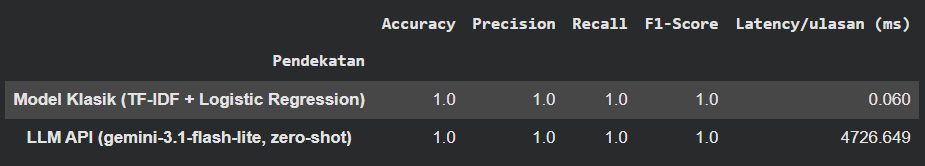

In [84]:
def ringkas(nama, y_true, y_pred, latency):
    kwargs = dict(labels=[0, 1], average='macro', zero_division=0)
    return {
        'Pendekatan': nama,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, **kwargs),
        'Recall': recall_score(y_true, y_pred, **kwargs),
        'F1-Score': f1_score(y_true, y_pred, **kwargs),
        'Latency/ulasan (ms)': latency * 1000,
    }

tabel_perbandingan = pd.DataFrame([
    ringkas('Model Klasik (TF-IDF + Logistic Regression)', y_test, y_pred_classic, latency_classic),
    ringkas(f'LLM API ({MODEL_NAME}, zero-shot)', y_test, y_pred_llm, latency_llm),
]).set_index('Pendekatan').round(3)
tabel_perbandingan


,Accuracy,Precision,Recall,F1-Score,Latency/ulasan (ms)
Pendekatan,,,,,
Model Klasik (TF-IDF + Logistic Regression),1.0,1.0,1.0,1.0,0.060
"LLM API (gemini-3.1-flash-lite, zero-shot)",1.0,1.0,1.0,1.0,4726.649


In [85]:
# ===== Hasil prediksi per pendekatan =====
hasil_classic = pd.DataFrame({
    'review_text': X_test,
    'label_asli': y_test,
    'pred_classic': y_pred_classic,
})
hasil_classic['benar'] = hasil_classic['label_asli'] == hasil_classic['pred_classic']
hasil_llm['benar'] = hasil_llm['label_asli'] == y_pred_llm

hasil_classic.to_csv('hasil_prediksi_klasik.csv', index=False)
hasil_llm.to_csv('hasil_prediksi_llm.csv', index=False)

# ===== Metrik & confusion matrix per pendekatan =====
def simpan_evaluasi(nama_file, y_true, y_pred):
    report = classification_report(y_true, y_pred, labels=[0, 1], target_names=['negatif (0)', 'positif (1)'],
                                   zero_division=0, output_dict=True)
    pd.DataFrame(report).T.round(3).to_csv(f'{nama_file}_metrik.csv')

    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=[0, 1]),
                      index=['asli_negatif', 'asli_positif'], columns=['pred_negatif', 'pred_positif'])
    cm.to_csv(f'{nama_file}_confusion_matrix.csv')

simpan_evaluasi('klasik', y_test, y_pred_classic)
simpan_evaluasi('llm', y_test, y_pred_llm)

# ===== Tabel ringkasan =====
tabel_perbandingan.to_csv('tabel_perbandingan.csv')

print('Semua file tersimpan.')

Semua file tersimpan.


## 7. Analisis Trade-off dan Limitation

### 7.1 Performa
Eksperimen dijalankan dalam dua skenario, yaitu dengan dan tanpa drop duplicate (lihat 7.3). Pada kedua skenario, model klasik dan Gemini sama-sama mendapat skor sempurna, dan tidak ada output Gemini yang tidak valid.

| Skenario | Test set | Model Klasik (Acc / P / R / F1) | Gemini (Acc / P / R / F1) | Confusion matrix (keduanya) |
|---|---|---|---|---|
| Dengan drop duplicate | 8 ulasan unik | 1.0 | 1.0 | `[[4 0] [0 4]]` |
| Tanpa drop duplicate | 40 baris (26 ulasan unik) | 1.0 | 1.0 | `[[18 0] [0 22]]` |

Artinya, **dari sisi performa kedua pendekatan seri pada eksperimen ini**. Hasil ini belum bisa dipakai untuk menyimpulkan pendekatan mana yang lebih akurat, karena test set kecil dan ulasannya mudah. Semua ulasan memakai kata sentimen yang eksplisit, seperti "puas", "lambat", atau "tidak sesuai". Karena akurasinya seri, pembeda utama kedua pendekatan ada pada faktor non-akurasi di bawah.

### 7.2 Trade-off

| Aspek | Model Klasik (TF-IDF + Logistic Regression) | LLM API (Gemini 3.1 Flash-Lite, zero-shot) |
|---|---|---|
| **Effort awal** | Butuh data berlabel dan proses training | Tidak butuh data training, cukup merancang prompt |
| **Latency per ulasan** | **0,06 ms** (proses lokal, 40 ulasan diprediksi sekaligus) | **±4,7 detik** rata-rata (median ±3,5 detik, rentang 1,3–14,2 detik), lewat jaringan ke server Google. Sekitar **79.000x lebih lambat** |
| **Biaya** | Praktis gratis setelah training, cukup CPU biasa | Bayar per token; biaya naik seiring jumlah ulasan |
| **Ketersediaan** | Berjalan lokal, tidak bergantung pihak luar | Bergantung server Google. Selama eksperimen beberapa kali muncul error **503 (server sibuk)** sehingga perlu mekanisme retry |
| **Stabilitas versi** | Model tidak berubah selama tidak dilatih ulang | Model bisa dihentikan penyedia. Selama eksperimen `gemini-2.0-flash` dan `gemini-2.5-flash` sudah **tidak tersedia (404)**, sehingga kode harus diganti ke model baru |
| **Konsistensi output** | Deterministik, output selalu 0/1 | Output berupa teks bebas, perlu diparsing dan dinormalisasi. Temperature 0 mengurangi variasi, tapi tidak menjamin format selalu sesuai |
| **Privasi data** | Data ulasan tetap di sistem sendiri | Teks ulasan dikirim ke pihak ketiga |
| **Interpretabilitas** | Bobot kata dari Logistic Regression bisa dilihat dan dijelaskan | Sulit dijelaskan mengapa sebuah label dipilih (black box) |
| **Generalisasi** | Hanya mengenal kosakata di data training; kata baru diabaikan | *(Dugaan, belum diuji)* Lebih mampu memahami kosakata baru, bahasa gaul, sarkasme, dan kalimat campuran karena dilatih dengan data yang sangat luas |
| **Perawatan** | Perlu dilatih ulang jika pola ulasan berubah (data drift) | Tidak perlu training ulang, tetapi perlu menyesuaikan kode saat versi model berganti |

### 7.3 Perbandingan: Dengan vs Tanpa Drop Duplicate
Dataset berisi 200 baris, tetapi hanya 40 ulasan unik. Untuk melihat pengaruh duplikat, split data dijalankan dalam dua skenario dengan parameter yang sama (`test_size=0.2`, `random_state=42`, `stratify`).

| | Dengan drop duplicate | Tanpa drop duplicate |
|---|---|---|
| Train / test | 32 / 8 | 160 / 40 |
| Ulasan unik di test set | 8 | 26 |
| Ulasan test yang juga ada di train set | **0** | **25 dari 26 ulasan unik** (39 dari 40 baris) |
| Skor model klasik | 1.0 | 1.0 |
| Skor Gemini | 1.0 | 1.0 |
| Ulasan yang perlu dikirim ke Gemini | 8 | 40 baris (26 teks unik; teks yang sama diambil dari cache) |

**Angkanya sama, tetapi maknanya berbeda:**
- **Tanpa drop duplicate**, hampir semua ulasan test sudah pernah dilihat model klasik saat training (data leakage). Skor 1.0 di skenario ini hanya menunjukkan model mampu *mengingat* teks yang sama, bukan memprediksi ulasan baru.
- **Dengan drop duplicate**, tidak ada ulasan test yang ada di train set, sehingga skor 1.0 benar-benar menunjukkan kemampuan model pada ulasan yang belum pernah dilihat. Karena itu **skenario dengan drop duplicate dipakai sebagai dasar evaluasi utama**.
- **Gemini tidak terpengaruh leakage** karena tidak dilatih dengan data train. Namun tanpa deduplikasi, Gemini dipanggil untuk teks yang berulang, sehingga biaya dan waktu bertambah tanpa menambah informasi baru.
- Skor yang tetap 1.0 walaupun tanpa leakage juga menegaskan bahwa **dataset ini terlalu mudah** untuk membedakan kedua pendekatan.

### 7.4 Limitation Eksperimen
1. **Dataset sangat kecil dan berulang.** Dari 200 baris hanya ada 40 ulasan unik (sisanya duplikat), sehingga setelah deduplikasi hanya tersisa 32 data train dan 8 data test.
2. **Test set terlalu kecil.** Pada skenario utama, satu kesalahan prediksi saja sudah menurunkan akurasi 12,5%, sehingga skor 1.0 tidak cukup kuat untuk membedakan kedua pendekatan.
3. **Ulasan terlalu mudah dan seragam.** Tidak ada ulasan netral, sarkasme, bahasa gaul, typo, atau ulasan campuran (positif dan negatif sekaligus) seperti yang umum di e-commerce sungguhan.
4. **Hanya satu konfigurasi per pendekatan.** Model klasik hanya diuji dengan Logistic Regression, dan Gemini hanya dengan satu model dan prompt zero-shot tanpa perbandingan few-shot.
5. **Hanya satu kali percobaan.** Tidak ada pengulangan dengan random split berbeda (misalnya cross-validation), sehingga hasil bisa kebetulan bergantung pada ulasan yang terpilih.
6. **Angka latency hanya perkiraan, bukan angka pasti.**
   - Waktu Gemini ikut dipengaruhi kecepatan internet dan waktu tunggu saat server sibuk (error 503). Contohnya, satu ulasan butuh 14,2 detik karena harus dicoba ulang, padahal ulasan lain rata-rata hanya 1–6 detik.
   - 9 dari 40 ulasan tidak tercatat waktunya karena hasilnya diambil dari percobaan sebelumnya, sehingga rata-rata dihitung dari 31 ulasan saja.
   - Model klasik diukur dengan memprediksi 40 ulasan sekaligus, lalu waktunya dibagi rata. Jika ulasan diprediksi satu per satu, waktunya bisa sedikit lebih lama.

   Meski begitu, hasilnya tetap jelas: model klasik jauh lebih cepat (hitungan milidetik) dibanding Gemini (hitungan detik).
7. **Biaya belum dihitung secara aktual.** Biaya per prediksi Gemini belum diukur dari jumlah token yang benar-benar terpakai.
8. **Label diasumsikan benar.** Tidak ada pengecekan ulang terhadap kualitas label di dataset.

## 8. Rekomendasi Technical Approach

### Kesimpulan dari eksperimen
Dari sisi akurasi, eksperimen ini **belum bisa menentukan pendekatan mana yang lebih baik**. Kedua pendekatan sama-sama mendapat skor 1.0, karena dataset kecil (hanya 40 ulasan unik) dan ulasannya relatif mudah serta mirip satu sama lain. Perbedaan yang terlihat jelas justru ada pada kecepatan, biaya, dan effort.

| | Model Klasik | LLM API (Gemini) |
|---|---|---|
| Kelebihan | Sangat cepat (±0,06 ms/ulasan), hampir tanpa biaya, berjalan lokal | Tidak perlu membuat dataset dan training, cukup merancang prompt |
| Kekurangan | Butuh dataset berlabel yang bagus dan cukup banyak | Lebih lambat (±4,7 detik/ulasan), ada biaya per panggilan, bergantung pada server Google |

### Rekomendasi
1. **Untuk sistem produksi jangka panjang, pilih model klasik**, dengan syarat tim menyiapkan dataset yang lebih besar dan bervariasi. Fitur ini akan memproses banyak ulasan setiap hari, sehingga kecepatan dan biaya rendah menjadi faktor penting.
2. **Jika tim ingin fitur cepat jadi tanpa menyiapkan dataset, gunakan LLM API**, dengan konsekuensi biaya per ulasan yang lebih tinggi dan respons yang lebih lambat.
3. **Kombinasi keduanya:** gunakan Gemini untuk membantu memberi label awal pada ulasan-ulasan baru (dicek ulang oleh manusia), lalu hasilnya dipakai untuk melatih model klasik. Dengan cara ini, effort membuat dataset berkurang, sementara sistem produksi tetap cepat dan murah.

### Langkah selanjutnya
Sebelum keputusan final, eksperimen perlu diulang dengan dataset yang lebih besar dan lebih beragam, misalnya ulasan asli dari platform yang berisi bahasa gaul, typo, sarkasme, atau ulasan campuran. Dengan data seperti itu, perbedaan akurasi kedua pendekatan baru bisa terlihat, dan rekomendasi bisa diambil dengan lebih yakin.
